In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read in data from the Nulisa assay
# which was sent to us by 
df = pd.read_excel('../data/NULISA_for_upload.xlsx')
df.head()

,targetName,P08_C1_D1_BMA,P08_C1_D1_PB,P08_C7_D1_BMA,P08_C7_D1_PB,P24_C1_D1_BMA,P24_C1_D1_PB,P24_C7_D1_BMA,P24_C7_D1_PB,P12_C1_D1_BMA,...,IPC3,NC1,NC2,NC3,NC4,RNBMA_Plasma,RNPB_Plasma,SC1,SC2,SC3
0,AGER,8.098874,12.815814,10.048087,13.426360,10.186972,13.409686,9.607677,12.971496,10.819983,...,13.287857,0.000000,0.000000,0.000000,0.000000,14.652822,15.761617,13.515206,13.430871,13.215132
1,AGRP,7.261311,11.599770,9.653722,13.281680,9.498240,12.211211,10.164315,13.604866,9.289948,...,13.287857,4.197841,4.243510,0.000000,4.827565,12.537522,12.795884,13.320905,13.332838,13.281140
2,ANGPT1,11.176965,13.711416,11.570059,11.973600,11.134398,12.117352,10.437689,12.194923,9.876157,...,13.183936,6.291575,5.703534,6.492616,6.009174,12.041054,12.818809,13.341584,13.315648,13.046785
3,ANGPT2,8.961332,12.817818,9.927943,12.801492,11.676046,14.589588,11.971372,15.528098,9.929931,...,13.257715,0.000000,1.506642,2.048571,0.000000,12.311747,13.277203,13.408156,13.351494,13.179535
4,ANXA1,9.855022,11.558501,9.068268,11.336655,9.376385,9.848232,9.008491,9.886488,9.602541,...,13.287857,9.460188,9.281864,8.860607,8.714064,8.498531,10.190912,13.472023,13.352042,12.968113


In [3]:
# Calculate the background (which is the signal detected in the negative control well for each assay)
df['background'] = df[['NC1', 'NC2', 'NC3', 'NC4']].mean(axis=1)

In [4]:
# Transpose the df so that it easier to work with 
df.index = df['targetName']
df = df.iloc[:, 1:]
df = df.T
df

# select blood and bone marrow samples from the oral aza trial (these have _BMA or _PB in the title and lack 'RN')
df = df.loc[(df.index.str.contains('_BMA') | df.index.str.contains('_PB') | df.index.str.contains('background')) & (~df.index.str.contains('RN')), :]
df.head()

targetName,AGER,AGRP,ANGPT1,ANGPT2,ANXA1,AREG,BDNF,BMP7,BST2,C1QA,...,TREM1,TREM2,VCAM1,VEGFA,VEGFC,VEGFD,VSNL1,VSTM1,WNT16,WNT7A
P08_C1_D1_BMA,8.098874,7.261311,11.176965,8.961332,9.855022,8.826391,10.476133,10.957482,6.862759,8.990968,...,8.726599,7.940766,9.272499,11.652502,10.575666,8.022063,9.163231,10.833751,9.306676,6.368683
P08_C1_D1_PB,12.815814,11.599770,13.711416,12.817818,11.558501,9.357486,15.225674,11.779913,11.363372,12.427062,...,13.143437,12.017396,12.941936,15.142156,13.385485,7.592040,11.853413,14.683010,12.931866,8.744185
P08_C7_D1_BMA,10.048087,9.653722,11.570059,9.927943,9.068268,9.235046,9.005682,11.481258,7.992722,9.794737,...,9.923594,9.151399,10.754465,11.196261,10.928972,7.842120,9.814674,11.318856,10.098527,7.128281
P08_C7_D1_PB,13.426360,13.281680,11.973600,12.801492,11.336655,9.546682,11.610879,12.108913,11.263604,12.575250,...,12.639026,12.237741,13.337745,14.208861,13.273854,7.704273,11.770859,11.012886,13.143388,8.900478
P24_C1_D1_BMA,10.186972,9.498240,11.134398,11.676046,9.376385,9.196032,7.792804,11.939582,9.500984,10.703933,...,10.474709,9.921123,11.156053,11.185332,11.645861,7.479362,9.699821,9.703087,9.618251,7.059484


In [5]:
# Filter the dataframe to contain tissues of interest
df_bm = df.loc[df.index.str.contains('BMA') | df.index.str.contains('background'), :]
df_pb = df.loc[df.index.str.contains('PB') | df.index.str.contains('background'), :]

In [6]:
df_bm

targetName,AGER,AGRP,ANGPT1,ANGPT2,ANXA1,AREG,BDNF,BMP7,BST2,C1QA,...,TREM1,TREM2,VCAM1,VEGFA,VEGFC,VEGFD,VSNL1,VSTM1,WNT16,WNT7A
P08_C1_D1_BMA,8.098874,7.261311,11.176965,8.961332,9.855022,8.826391,10.476133,10.957482,6.862759,8.990968,...,8.726599,7.940766,9.272499,11.652502,10.575666,8.022063,9.163231,10.833751,9.306676,6.368683
P08_C7_D1_BMA,10.048087,9.653722,11.570059,9.927943,9.068268,9.235046,9.005682,11.481258,7.992722,9.794737,...,9.923594,9.151399,10.754465,11.196261,10.928972,7.842120,9.814674,11.318856,10.098527,7.128281
P24_C1_D1_BMA,10.186972,9.498240,11.134398,11.676046,9.376385,9.196032,7.792804,11.939582,9.500984,10.703933,...,10.474709,9.921123,11.156053,11.185332,11.645861,7.479362,9.699821,9.703087,9.618251,7.059484
P24_C7_D1_BMA,9.607677,10.164315,10.437689,11.971372,9.008491,9.229084,5.657140,11.684082,9.166457,10.118488,...,9.568449,9.249993,11.340800,11.444087,11.487908,7.219862,9.383797,8.369150,9.291615,7.172654
P12_C1_D1_BMA,10.819983,9.289948,9.876157,9.929931,9.602541,9.385368,8.716445,12.004127,9.768831,11.075143,...,11.886219,10.660304,11.163281,11.161162,11.265140,8.435425,9.841218,15.583702,9.961860,7.513310
P12_C12_D29_BMA,11.131146,8.984734,11.261507,9.929555,9.449461,9.360968,9.587266,11.967869,7.704947,10.924446,...,11.505781,10.349515,10.865192,11.364425,11.239247,8.169403,10.302380,11.979942,10.093513,7.633563
P12_C7_D1_BMA,11.030816,11.523446,11.244721,9.495427,9.213028,9.053431,9.845438,12.219942,7.512179,11.046618,...,11.880961,11.560107,11.269157,11.066902,11.511364,8.175193,9.978296,9.012725,10.588104,7.592700
P04_C1_D1_BMA,9.669197,8.896415,9.564687,10.059196,9.530766,9.160668,0.000000,12.146258,7.939870,10.578731,...,10.789858,9.643534,10.958214,11.109024,10.956678,7.390128,9.601547,13.427774,9.534613,6.741929
P04_C12_D29_BMA,9.925224,9.324275,10.089530,10.602417,8.865842,9.607916,0.000000,12.124482,8.586321,10.472077,...,11.459167,10.260862,11.101086,11.622765,11.052383,7.191839,9.823034,13.137505,9.757403,6.762570
P04_C7_D1_BMA,8.206848,9.888090,10.690165,9.674601,9.017420,8.876882,9.260429,11.864299,7.395496,9.776727,...,10.245408,10.660743,10.787613,11.616356,10.963319,6.571319,9.360706,7.984153,9.399018,7.432728


In [7]:
# Calculate the percentage of bone marrow samples in which a cytokine
# is detected above background
last_row = df_bm.iloc[-1] # last row is the background signal for each molecule
result_df_bm = (df_bm > last_row).sum().to_frame('Count')
result_df_bm['Percentage'] = ((result_df_bm['Count'] / (len(df_bm) - 1)) * 100).round(2).astype(int)

# print("\nPercentage of values greater than the last row in each column:")
# print(result_df_bm)


Percentage of values greater than the last row in each column:
            Count  Percentage
targetName                   
AGER           46         100
AGRP           46         100
ANGPT1         46         100
ANGPT2         46         100
ANXA1          40          86
...           ...         ...
VEGFD          46         100
VSNL1          46         100
VSTM1          46         100
WNT16          46         100
WNT7A          46         100

[247 rows x 2 columns]


In [8]:
# Calculate the percentage of blood samples in which a cytokine is detected above background
last_row = df_pb.iloc[-1]
result_df_pb = (df_pb > last_row).sum().to_frame('Count')
result_df_pb['Percentage'] = ((result_df_pb['Count'] / (len(df_pb) - 1)) * 100).round(2).astype(int)

# print("\nPercentage of values greater than the last row in each column:")
# print(result_df_bm)


Percentage of values greater than the last row in each column:
            Count  Percentage
targetName                   
AGER           46         100
AGRP           46         100
ANGPT1         46         100
ANGPT2         46         100
ANXA1          40          86
...           ...         ...
VEGFD          46         100
VSNL1          46         100
VSTM1          46         100
WNT16          46         100
WNT7A          46         100

[247 rows x 2 columns]


0 84


<ipython-input-9-b7f9278e0f3c>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels = result_df_bm.iloc[x:y,].index, rotation = 90)


85 168
169 247


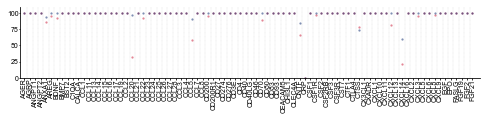

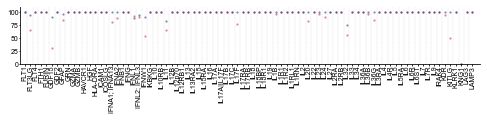

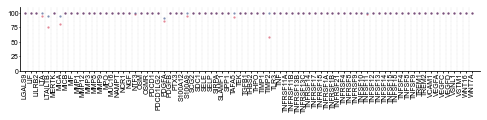

In [9]:
# Plot some graphs which detail the percentage of molecules which were above background in 
# blood and bone marrow
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

for x, y in zip([0, 85, 169], [84, 168, 247]):   
    print(x, y)
    fig, ax = plt.subplots(figsize = (6.1, 1))
    ax.scatter(x = result_df_bm.iloc[x:y,].index, y = result_df_bm.loc[result_df_bm.index[x:y], 'Percentage'], 
               color = '#C8102EFF', s = 5, alpha = 0.5, linewidth = 0)
    ax.scatter(x = result_df_pb.iloc[x:y].index, y = result_df_pb.loc[result_df_pb.index[x:y], 'Percentage'], 
               color = '#012169FF', s = 5, alpha = 0.5, linewidth = 0)

    ax.set_xlim(-0.75, 0.5 + len(result_df_bm.iloc[x:y,].index))
    ax.set_xticklabels(labels = result_df_bm.iloc[x:y,].index, rotation = 90)
    ax.tick_params(axis='both', labelsize=7, pad = 0.1, length = 1.5)  
    ax.set_yticks(ticks = [0, 25, 50, 75, 100], labels = [0, 25, 50, 75, 100])

    
    ax.set_ylim(bottom = 0, top = 110)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for i in range((y-x) -1):
        ax.axvline(x= i + 0.5, ymax =1, color='silver', linestyle='--', linewidth=0.25)
    
    fig.set_size_inches(6.6, 1.5)
    fig.tight_layout(pad=0.1)
    #fig.savefig('../detection_graphs/molecules' + str(x) +'_' + str(y) +'.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 300)